## Without Data Augmentation

In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.applications.vgg16 import VGG16

In [2]:
conv_base = VGG16(
    weights = 'imagenet',
    include_top = False, # Since the top layer is output layer -  and we do not want to include is so well mark it False
    input_shape = (150,150,3)
)

In [3]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [4]:
# We will create our own fully connected part
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 16,812,353
Non-trainable params: 0
_________________________________________________________________


In [6]:
conv_base.trainable = False
# This will not allow the convolution layer to retrain - as we want same weights and biases

In [14]:
# generators

train_ds = keras.utils.image_dataset_from_directory(
    directory = 'ImageData/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 5,
    image_size = (150,150)
)

# for validation
validation_ds = keras.utils.image_dataset_from_directory(
    directory = 'ImageData/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 5,
    image_size = (150,150)
)

Found 5000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [8]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
history = model.fit(train_ds,epochs=5,validation_data=validation_ds)

Epoch 1/5


1000/1000 [==============================] - 273s 273ms/step - loss: 1.2599 - accuracy: 0.9322 - val_loss: 0.6176 - val_accuracy: 0.5678
Epoch 2/5
1000/1000 [==============================] - 267s 267ms/step - loss: 0.0634 - accuracy: 0.9812 - val_loss: 0.5886 - val_accuracy: 0.6082
Epoch 3/5
1000/1000 [==============================] - 275s 275ms/step - loss: 0.0427 - accuracy: 0.9876 - val_loss: 0.6173 - val_accuracy: 0.5606
Epoch 4/5
1000/1000 [==============================] - 275s 275ms/step - loss: 0.0232 - accuracy: 0.9938 - val_loss: 0.5736 - val_accuracy: 0.6812
Epoch 5/5
1000/1000 [==============================] - 287s 287ms/step - loss: 0.0343 - accuracy: 0.9886 - val_loss: 0.6101 - val_accuracy: 0.5796


In [16]:
import matplotlib.pyplot as plt

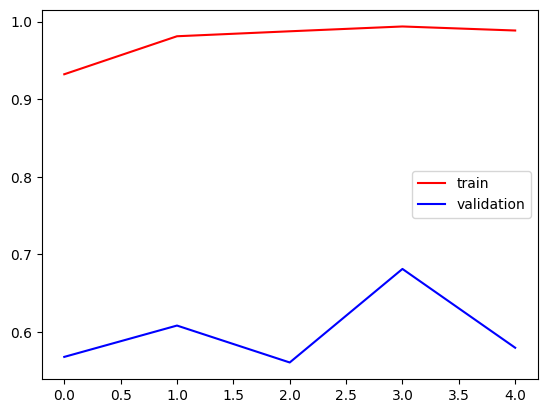

In [17]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

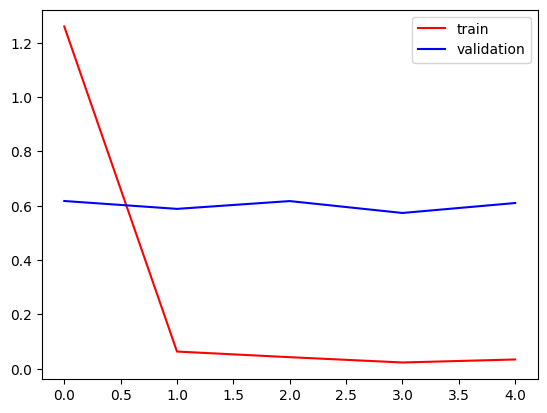

In [18]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()